# Customer Purchase Prediction from E-Commerce

**Algorithms Used**
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. KNN 

**Target Variable:** `PurchaseStatus`

This notebook follows the required ML workflow: data understanding, cleaning and preprocessing, EDA, train-test split, model training, evaluation, comparison, best-model selection, final prediction, and conclusion.


## 1. Import Libraries

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Dataset

In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

file_path = "/content/customer_purchase_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (1500, 9)


In [3]:
# Display the first 5 records

print(df.head())


   Age  Gender   AnnualIncome  NumberOfPurchases  ProductCategory  \
0   40       1   66120.267939                  8                0   
1   20       1   23579.773583                  4                2   
2   27       1  127821.306432                 11                2   
3   24       1  137798.623120                 19                3   
4   31       1   99300.964220                 19                1   

   TimeSpentOnWebsite  LoyaltyProgram  DiscountsAvailed  PurchaseStatus  
0           30.568601               0                 5               1  
1           38.240097               0                 5               0  
2           31.633212               1                 0               1  
3           46.167059               0                 4               1  
4           19.823592               0                 0               1  


## 3. Data Understanding

In [4]:
# ============================================================
# 3. DATA UNDERSTANDING
# ============================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(df.info())


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB
None


In [5]:
# Dataset shape, columns and data types

print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


Number of rows    : 1500
Number of columns : 9

Column Names:
['Age', 'Gender', 'AnnualIncome', 'NumberOfPurchases', 'ProductCategory', 'TimeSpentOnWebsite', 'LoyaltyProgram', 'DiscountsAvailed', 'PurchaseStatus']

Data Types:
Age                     int64
Gender                  int64
AnnualIncome          float64
NumberOfPurchases       int64
ProductCategory         int64
TimeSpentOnWebsite    float64
LoyaltyProgram          int64
DiscountsAvailed        int64
PurchaseStatus          int64
dtype: object


In [6]:
# Statistical summary

print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

print(df.describe())


STATISTICAL SUMMARY
               Age       Gender   AnnualIncome  NumberOfPurchases  \
count  1500.000000  1500.000000    1500.000000        1500.000000   
mean     44.298667     0.504667   84249.164338          10.420000   
std      15.537259     0.500145   37629.493078           5.887391   
min      18.000000     0.000000   20001.512518           0.000000   
25%      31.000000     0.000000   53028.979155           5.000000   
50%      45.000000     1.000000   83699.581476          11.000000   
75%      57.000000     1.000000  117167.772858          15.000000   
max      70.000000     1.000000  149785.176481          20.000000   

       ProductCategory  TimeSpentOnWebsite  LoyaltyProgram  DiscountsAvailed  \
count      1500.000000         1500.000000     1500.000000       1500.000000   
mean          2.012667           30.469040        0.326667          2.555333   
std           1.428005           16.984392        0.469151          1.705152   
min           0.000000            1.03

In [7]:
# Target variable distribution

print("=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)

print(df["PurchaseStatus"].value_counts())
print("\nTarget percentage:")
print(df["PurchaseStatus"].value_counts(normalize=True).mul(100).round(2))


TARGET DISTRIBUTION
PurchaseStatus
0    852
1    648
Name: count, dtype: int64

Target percentage:
PurchaseStatus
0    56.8
1    43.2
Name: proportion, dtype: float64


### Feature and Target Definition

- **Features (X):** all columns except `PurchaseStatus`
- **Target (y):** `PurchaseStatus`
- `PurchaseStatus = 0` represents no purchase.
- `PurchaseStatus = 1` represents purchase.


## 4. Data Cleaning & Preprocessing

In [8]:
# ============================================================
# 4. DATA CLEANING
# ============================================================

print("Missing values before cleaning:")
print(df.isnull().sum())

print("\nTotal duplicate rows:", df.duplicated().sum())


Missing values before cleaning:
Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64

Total duplicate rows: 112


In [9]:
# Remove duplicate records

before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates :", after)
print("Duplicates removed             :", before - after)


Rows before removing duplicates: 1500
Rows after removing duplicates : 1388
Duplicates removed             : 112


In [10]:
# Check missing values after cleaning

print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64


In [11]:
# Check for invalid target values

print("Unique PurchaseStatus values:", sorted(df["PurchaseStatus"].unique()))

if not df["PurchaseStatus"].isin([0, 1]).all():
    raise ValueError("PurchaseStatus contains values other than 0 and 1.")

print("Target variable is valid for binary classification.")


Unique PurchaseStatus values: [np.int64(0), np.int64(1)]
Target variable is valid for binary classification.


In [12]:
# Separate features and target

X = df.drop("PurchaseStatus", axis=1)
y = df["PurchaseStatus"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("PurchaseStatus")


Features:
['Age', 'Gender', 'AnnualIncome', 'NumberOfPurchases', 'ProductCategory', 'TimeSpentOnWebsite', 'LoyaltyProgram', 'DiscountsAvailed']

Target:
PurchaseStatus


### Preprocessing Note

The dataset already represents categorical/binary variables as numeric values, so no additional one-hot encoding is required for the supplied data.

Feature scaling is useful for **Logistic Regression**, so a `StandardScaler` is applied inside a pipeline. Decision Tree and Random Forest do not require feature scaling.


## 5. Exploratory Data Analysis (EDA)

### Graph 1 — Purchase Status Distribution

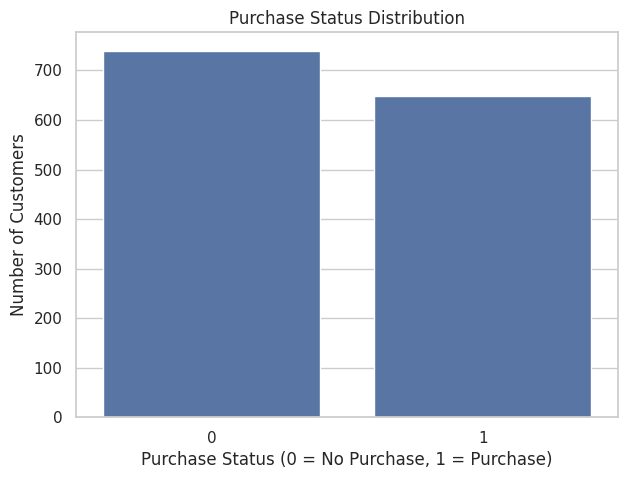

In [13]:
# ============================================================
# GRAPH 1: PURCHASE STATUS DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="PurchaseStatus")

plt.title("Purchase Status Distribution")
plt.xlabel("Purchase Status (0 = No Purchase, 1 = Purchase)")
plt.ylabel("Number of Customers")
plt.show()


In [14]:
# Insight for Graph 1

purchase_counts = df["PurchaseStatus"].value_counts().sort_index()

print("Graph 1 Insight:")
print(
    f"No Purchase (0): {purchase_counts.get(0, 0)} customers"
)
print(
    f"Purchase (1): {purchase_counts.get(1, 0)} customers"
)


Graph 1 Insight:
No Purchase (0): 740 customers
Purchase (1): 648 customers


### Graph 2 — Age Distribution by Purchase Status

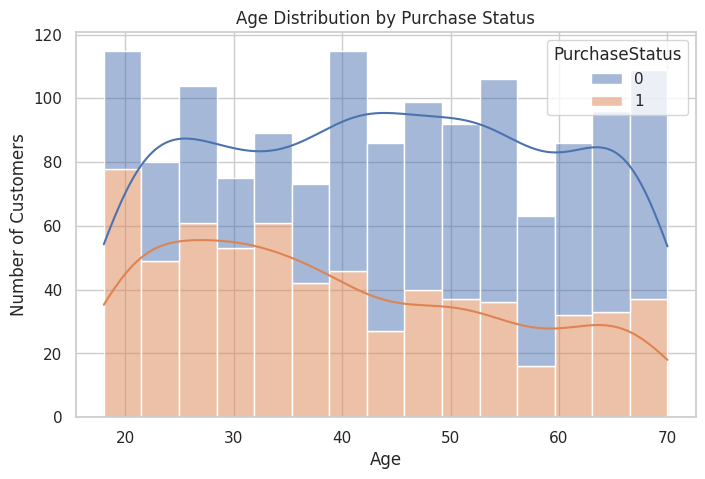

In [15]:
# ============================================================
# GRAPH 2: AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    hue="PurchaseStatus",
    bins=15,
    kde=True,
    multiple="stack"
)

plt.title("Age Distribution by Purchase Status")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()


**Insight:** This graph helps identify whether the age distribution differs between customers who purchased and those who did not.


### Graph 3 — Annual Income vs Purchase Status

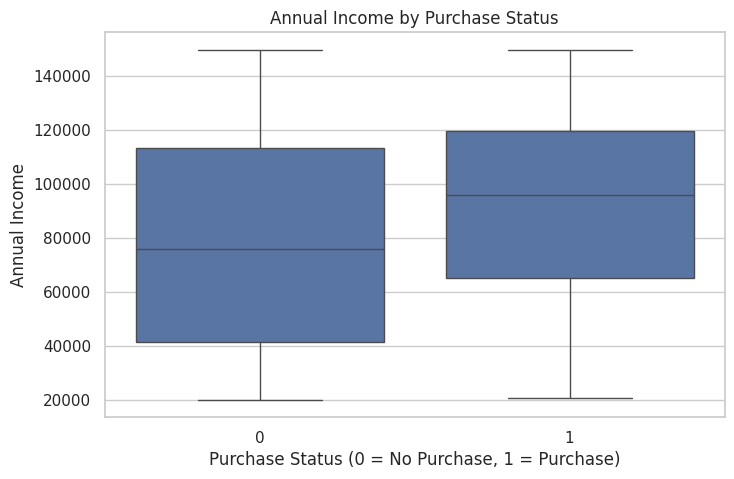

In [16]:
# ============================================================
# GRAPH 3: ANNUAL INCOME BOX PLOT
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="PurchaseStatus",
    y="AnnualIncome"
)

plt.title("Annual Income by Purchase Status")
plt.xlabel("Purchase Status (0 = No Purchase, 1 = Purchase)")
plt.ylabel("Annual Income")
plt.show()


**Insight:** The box plot compares the income distribution of purchasing and non-purchasing customers and helps identify possible differences and outliers.


### Graph 4 — Time Spent on Website

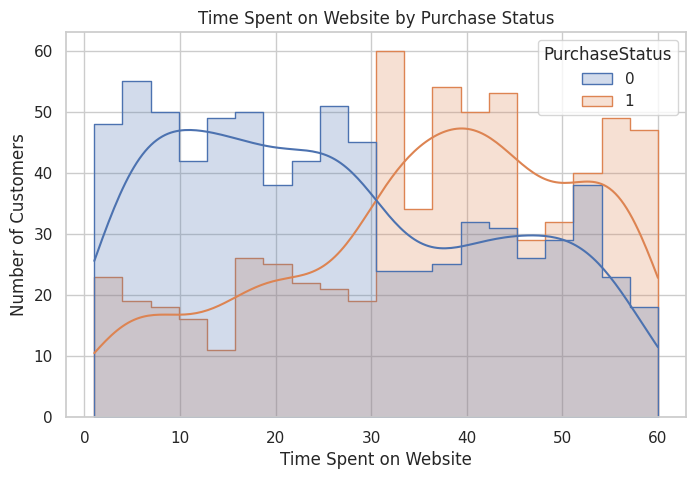

In [17]:
# ============================================================
# GRAPH 4: TIME SPENT ON WEBSITE
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="TimeSpentOnWebsite",
    hue="PurchaseStatus",
    bins=20,
    kde=True,
    element="step"
)

plt.title("Time Spent on Website by Purchase Status")
plt.xlabel("Time Spent on Website")
plt.ylabel("Number of Customers")
plt.show()


**Insight:** This visualization shows whether customers who spend more time on the website tend to have a different purchase pattern.


### Graph 5 — Loyalty Program vs Purchase Status

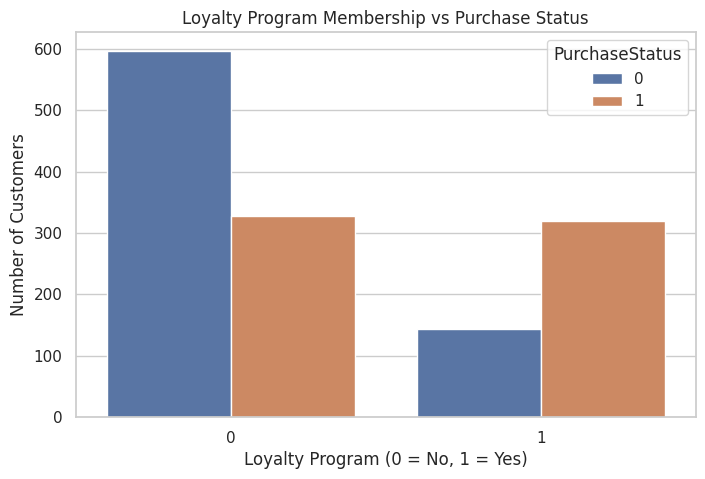

In [18]:
# ============================================================
# GRAPH 5: LOYALTY PROGRAM VS PURCHASE STATUS
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="LoyaltyProgram",
    hue="PurchaseStatus"
)

plt.title("Loyalty Program Membership vs Purchase Status")
plt.xlabel("Loyalty Program (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()


**Insight:** This graph compares purchase behavior between loyalty-program and non-loyalty-program customers.


### Graph 6 — Correlation Heatmap

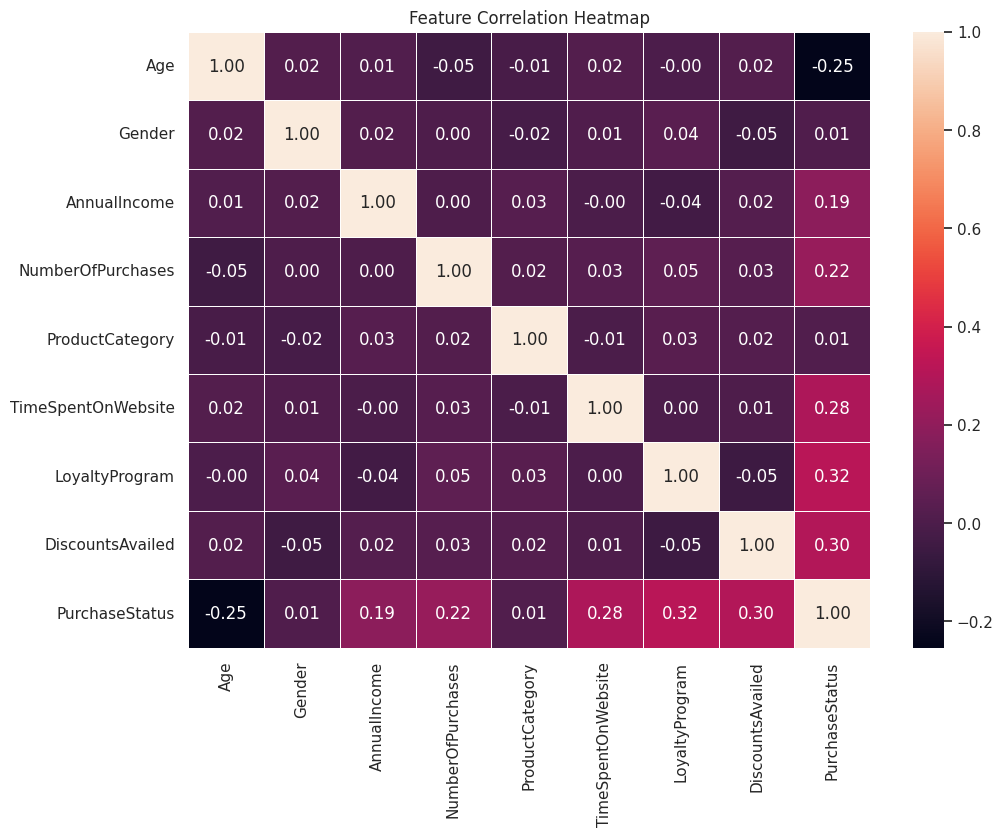

In [19]:
# ============================================================
# GRAPH 6: CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(11, 8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()


In [20]:
# Correlation with the target

print("Correlation with PurchaseStatus:")
print(
    correlation_matrix["PurchaseStatus"]
    .sort_values(ascending=False)
)


Correlation with PurchaseStatus:
PurchaseStatus        1.000000
LoyaltyProgram        0.318059
DiscountsAvailed      0.296606
TimeSpentOnWebsite    0.282127
NumberOfPurchases     0.219116
AnnualIncome          0.191218
ProductCategory       0.014349
Gender                0.008856
Age                  -0.253598
Name: PurchaseStatus, dtype: float64


**Insight:** The heatmap shows the strength and direction of linear relationships among the variables and the target.


### Graph 7 — Number of Purchases vs Purchase Status

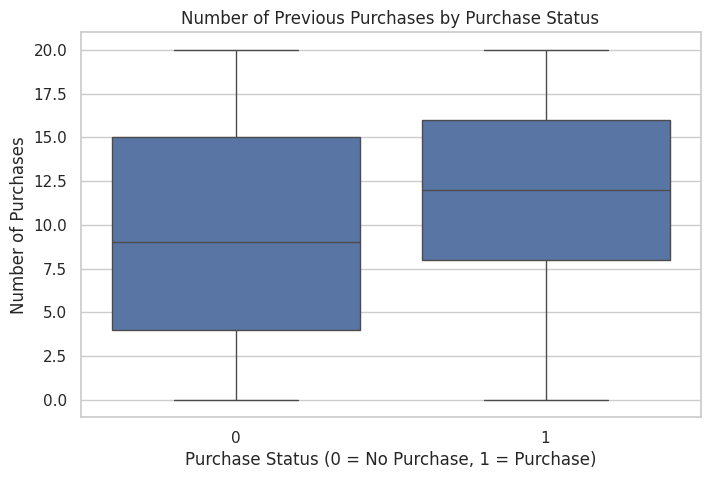

In [21]:
# ============================================================
# GRAPH 7: NUMBER OF PURCHASES
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="PurchaseStatus",
    y="NumberOfPurchases"
)

plt.title("Number of Previous Purchases by Purchase Status")
plt.xlabel("Purchase Status (0 = No Purchase, 1 = Purchase)")
plt.ylabel("Number of Purchases")
plt.show()


**Insight:** This visualization compares previous purchase activity between the two target classes.


## 6. Train-Test Split

In [22]:
# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("Training features:", X_train.shape[1])


Training samples: 1110
Testing samples : 278
Training features: 8


The dataset is split into **80% training data** and **20% testing data**. `stratify=y` keeps the class distribution similar in the training and testing sets.


# 7. Logistic Regression

### 7.1 Training

In [23]:
# ============================================================
# 7.1 LOGISTIC REGRESSION - TRAINING
# ============================================================

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


### 7.2 Prediction

In [24]:
# ============================================================
# 7.2 LOGISTIC REGRESSION - PREDICTION
# ============================================================

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

print("First 10 predictions:")
print(y_pred_lr[:10])

print("\nFirst 10 purchase probabilities:")
print(np.round(y_prob_lr[:10], 4))


First 10 predictions:
[1 0 1 1 0 0 0 1 0 1]

First 10 purchase probabilities:
[0.9207 0.2063 0.8698 0.9874 0.4322 0.0299 0.3163 0.6802 0.1936 0.9792]


### 7.3 Evaluation

In [25]:
# ============================================================
# 7.3 LOGISTIC REGRESSION - EVALUATION
# ============================================================

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr, zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, zero_division=0)

print("=" * 60)
print("LOGISTIC REGRESSION PERFORMANCE")
print("=" * 60)
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["No Purchase", "Purchase"],
    zero_division=0
))


LOGISTIC REGRESSION PERFORMANCE
Accuracy : 0.8309
Precision: 0.8168
Recall   : 0.8231
F1 Score : 0.8199

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.84      0.84      0.84       148
    Purchase       0.82      0.82      0.82       130

    accuracy                           0.83       278
   macro avg       0.83      0.83      0.83       278
weighted avg       0.83      0.83      0.83       278



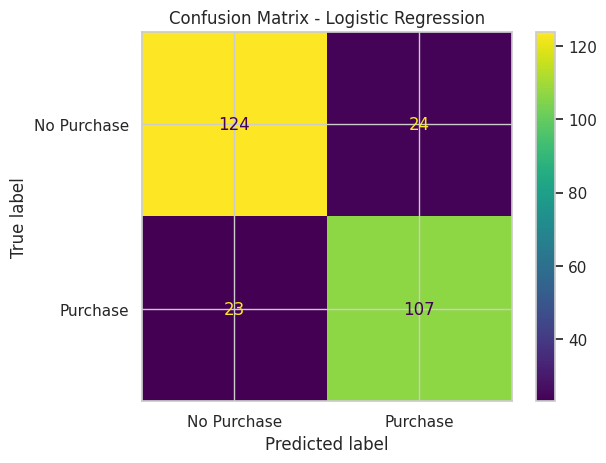

In [26]:
# Logistic Regression Confusion Matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["No Purchase", "Purchase"]
).plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()


# 8. Decision Tree

### 8.1 Training

In [27]:
# ============================================================
# 8.1 DECISION TREE - TRAINING
# ============================================================

decision_tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")


Decision Tree model trained successfully.


The Decision Tree uses **Gini impurity** as the splitting criterion, following the approach demonstrated in the reference Decision Tree notebook.


### 8.2 Prediction

In [28]:
# ============================================================
# 8.2 DECISION TREE - PREDICTION
# ============================================================

y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

print("First 10 predictions:")
print(y_pred_dt[:10])

print("\nFirst 10 purchase probabilities:")
print(np.round(y_prob_dt[:10], 4))


First 10 predictions:
[1 0 1 1 1 0 1 1 0 1]

First 10 purchase probabilities:
[0.9344 0.069  0.5238 0.9699 0.8409 0.069  0.8409 0.9516 0.069  0.95  ]


### 8.3 Evaluation

In [29]:
# ============================================================
# 8.3 DECISION TREE - EVALUATION
# ============================================================

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, zero_division=0)
dt_recall = recall_score(y_test, y_pred_dt, zero_division=0)
dt_f1 = f1_score(y_test, y_pred_dt, zero_division=0)

print("=" * 60)
print("DECISION TREE PERFORMANCE")
print("=" * 60)
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["No Purchase", "Purchase"],
    zero_division=0
))


DECISION TREE PERFORMANCE
Accuracy : 0.8525
Precision: 0.8201
Recall   : 0.8769
F1 Score : 0.8476

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.88      0.83      0.86       148
    Purchase       0.82      0.88      0.85       130

    accuracy                           0.85       278
   macro avg       0.85      0.85      0.85       278
weighted avg       0.85      0.85      0.85       278



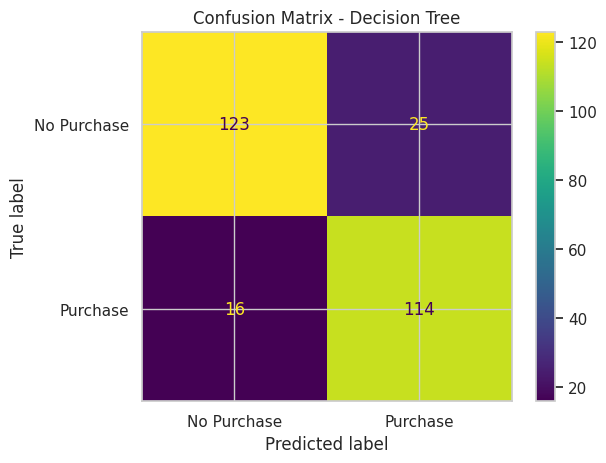

In [30]:
# Decision Tree Confusion Matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["No Purchase", "Purchase"]
).plot()

plt.title("Confusion Matrix - Decision Tree")
plt.show()


In [31]:
# Decision Tree Feature Importance

feature_importance_dt = pd.Series(
    decision_tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Decision Tree Feature Importance:")
print(feature_importance_dt)


Decision Tree Feature Importance:
TimeSpentOnWebsite    0.217957
LoyaltyProgram        0.177711
DiscountsAvailed      0.170732
AnnualIncome          0.167449
Age                   0.146449
NumberOfPurchases     0.119011
ProductCategory       0.000691
Gender                0.000000
dtype: float64


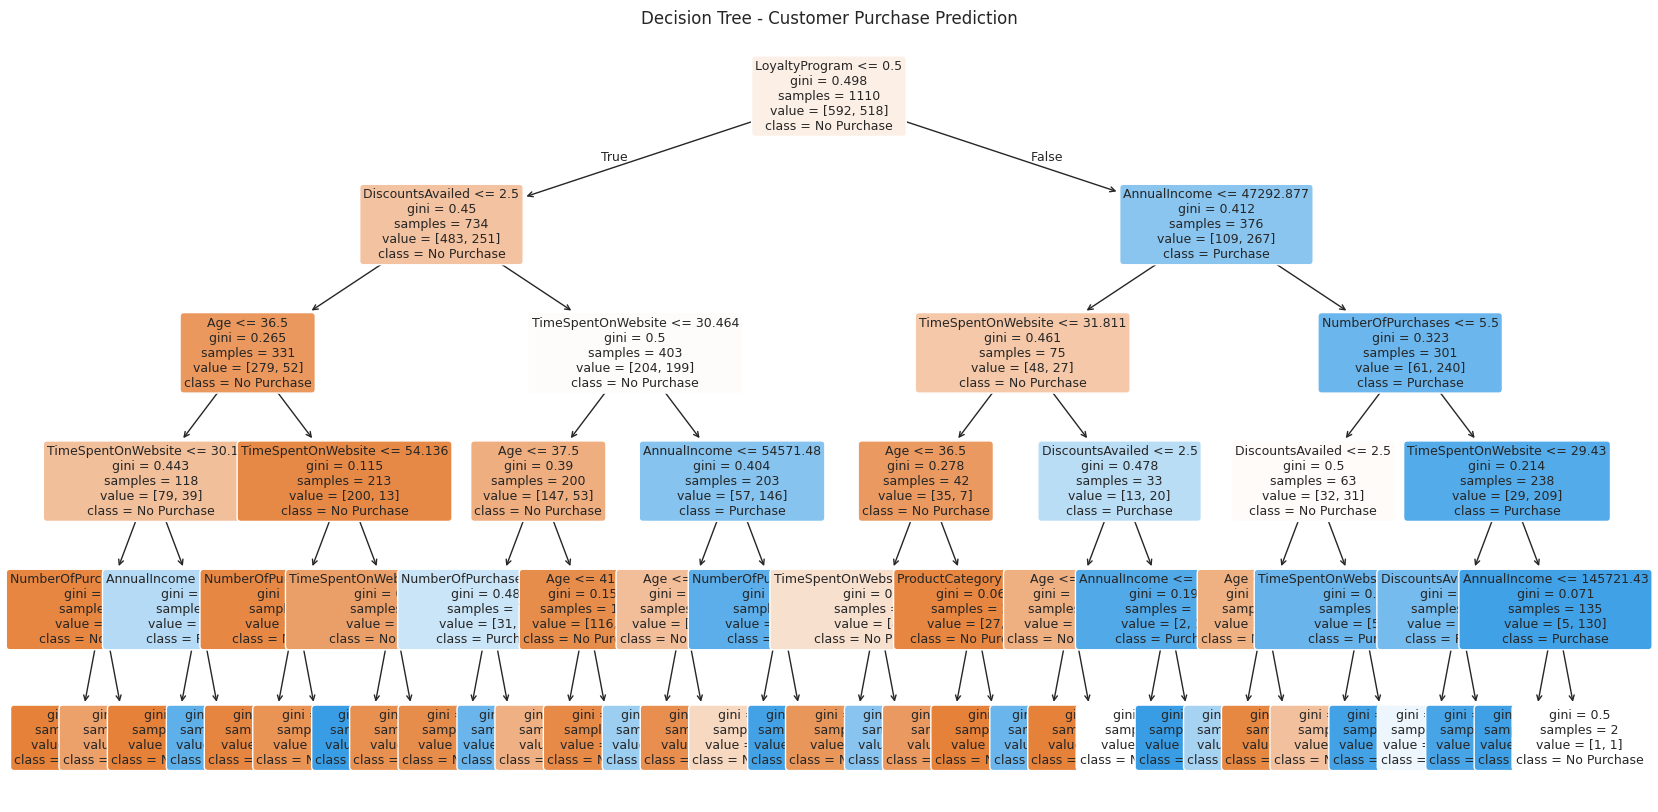

In [32]:
# Visualize the Decision Tree

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names=X.columns,
    class_names=["No Purchase", "Purchase"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree - Customer Purchase Prediction")
plt.show()


# 9. Random Forest

### 9.1 Training

In [33]:
# ============================================================
# 9.1 RANDOM FOREST - TRAINING
# ============================================================

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


The Random Forest uses multiple decision trees and combines their predictions. The reference Random Forest notebook also uses multiple estimators and evaluates the model with accuracy, precision, recall, F1-score and a confusion matrix.


### 9.2 Prediction

In [34]:
# ============================================================
# 9.2 RANDOM FOREST - PREDICTION
# ============================================================

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("First 10 predictions:")
print(y_pred_rf[:10])

print("\nFirst 10 purchase probabilities:")
print(np.round(y_prob_rf[:10], 4))


First 10 predictions:
[1 0 1 1 1 0 1 1 0 1]

First 10 purchase probabilities:
[0.6612 0.2741 0.5031 0.9871 0.8606 0.0651 0.5614 0.8043 0.1379 0.8309]


### 9.3 Evaluation

In [35]:
# ============================================================
# 9.3 RANDOM FOREST - EVALUATION
# ============================================================

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)

print("=" * 60)
print("RANDOM FOREST PERFORMANCE")
print("=" * 60)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Purchase", "Purchase"],
    zero_division=0
))


RANDOM FOREST PERFORMANCE
Accuracy : 0.9281
Precision: 0.9297
Recall   : 0.9154
F1 Score : 0.9225

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.93      0.94      0.93       148
    Purchase       0.93      0.92      0.92       130

    accuracy                           0.93       278
   macro avg       0.93      0.93      0.93       278
weighted avg       0.93      0.93      0.93       278



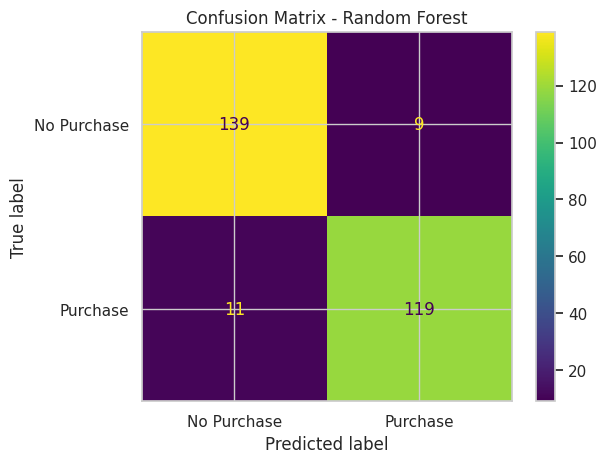

In [36]:
# Random Forest Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Purchase", "Purchase"]
).plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()


In [37]:
# Random Forest Feature Importance

feature_importance_rf = pd.Series(
    random_forest_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Random Forest Feature Importance:")
print(feature_importance_rf)


Random Forest Feature Importance:
TimeSpentOnWebsite    0.200957
Age                   0.176105
AnnualIncome          0.165712
DiscountsAvailed      0.144991
NumberOfPurchases     0.138214
LoyaltyProgram        0.122819
ProductCategory       0.035967
Gender                0.015235
dtype: float64


## 10. Model Comparison

In [38]:
# ============================================================
# 10. MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1-Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

comparison = comparison.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print(comparison.round(4))


                 Model  Accuracy  Precision  Recall  F1-Score
0        Random Forest    0.9281     0.9297  0.9154    0.9225
1        Decision Tree    0.8525     0.8201  0.8769    0.8476
2  Logistic Regression    0.8309     0.8168  0.8231    0.8199


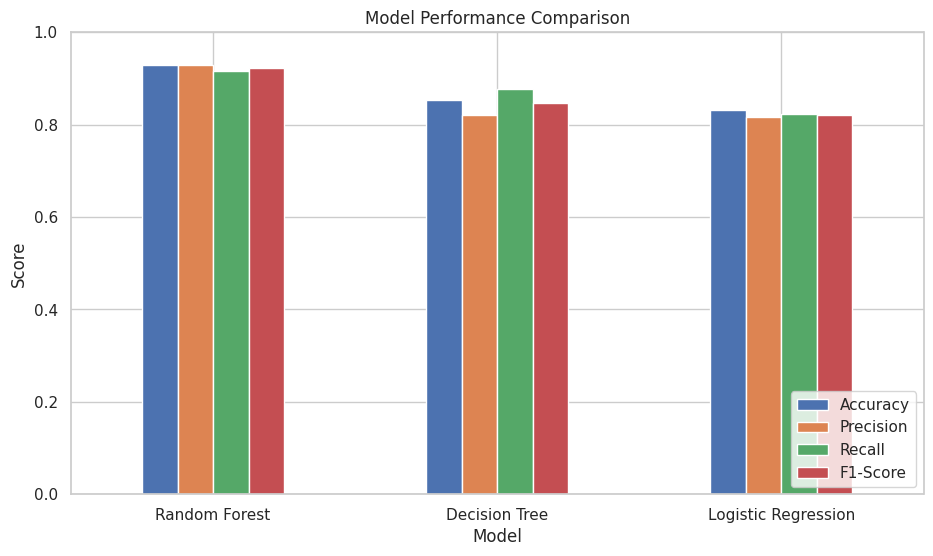

In [39]:
# Visual comparison of model performance

comparison_plot = comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()


The project requirements specify comparison using **Accuracy, Precision, Recall and F1-score** for classification problems. The model with the strongest overall performance should be selected as the best model.


## 11. Best Model

In [40]:
# ============================================================
# 11. BEST MODEL
# ============================================================

best_model_name = comparison.iloc[0]["Model"]
best_f1 = comparison.iloc[0]["F1-Score"]

model_objects = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

best_model = model_objects[best_model_name]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)
print("Best Model :", best_model_name)
print(f"F1-Score   : {best_f1:.4f}")

print("\nReason:")
print(
    "The model is selected because it has the highest F1-score "
    "among the three evaluated classification models."
)


BEST MODEL
Best Model : Random Forest
F1-Score   : 0.9225

Reason:
The model is selected because it has the highest F1-score among the three evaluated classification models.


## 12. Final Prediction

In [41]:
# ============================================================
# 12. FINAL PREDICTION
# ============================================================

# Example customer input
# Change these values to test another customer.

new_customer = pd.DataFrame({
    "Age": [30],
    "Gender": [1],
    "AnnualIncome": [80000],
    "NumberOfPurchases": [10],
    "ProductCategory": [2],
    "TimeSpentOnWebsite": [35],
    "LoyaltyProgram": [1],
    "DiscountsAvailed": [3]
})

print("New Customer:")
print(new_customer)


New Customer:
   Age  Gender  AnnualIncome  NumberOfPurchases  ProductCategory  \
0   30       1         80000                 10                2   

   TimeSpentOnWebsite  LoyaltyProgram  DiscountsAvailed  
0                  35               1                 3  


In [42]:
# Predict using the selected best model

final_prediction = best_model.predict(new_customer)[0]
final_probability = best_model.predict_proba(new_customer)[0][1]

print("=" * 60)
print("FINAL CUSTOMER PURCHASE PREDICTION")
print("=" * 60)

if final_prediction == 1:
    print("Prediction: CUSTOMER WILL PURCHASE")
else:
    print("Prediction: CUSTOMER WILL NOT PURCHASE")

print(f"Purchase Probability: {final_probability:.2%}")


FINAL CUSTOMER PURCHASE PREDICTION
Prediction: CUSTOMER WILL PURCHASE
Purchase Probability: 97.28%


## 13. Conclusion

In [43]:
# ============================================================
# 13. CONCLUSION
# ============================================================

print("=" * 70)
print("CONCLUSION")
print("=" * 70)

print(
    "Customer Purchase Prediction was performed using "
    "Logistic Regression, Decision Tree and Random Forest."
)

print(
    f"After comparing Accuracy, Precision, Recall and F1-score, "
    f"{best_model_name} achieved the highest F1-score."
)

print(
    "The selected model can be used to predict whether a customer "
    "is likely to make a purchase based on the available customer "
    "and website-behavior features."
)

print(
    "The project can be improved in the future using larger datasets, "
    "additional behavioral features, hyperparameter tuning and "
    "cross-validation."
)


CONCLUSION
Customer Purchase Prediction was performed using Logistic Regression, Decision Tree and Random Forest.
After comparing Accuracy, Precision, Recall and F1-score, Random Forest achieved the highest F1-score.
The selected model can be used to predict whether a customer is likely to make a purchase based on the available customer and website-behavior features.
The project can be improved in the future using larger datasets, additional behavioral features, hyperparameter tuning and cross-validation.
